In [72]:
import pandas as pd
import numpy as np

In [73]:
df_sent=pd.read_csv("fear_greed_index.csv")

In [74]:
df_sent.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [75]:

df_trad=pd.read_csv("historical_data.csv")

In [76]:
df_trad.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [77]:
#Date time

In [78]:
df_sent['date'] = pd.to_datetime(df_sent['date']).dt.date
df_trad['Timestamp'] = pd.to_datetime(df_trad['Timestamp']).dt.date

In [79]:
df_sent.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [80]:
df_trad.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01


In [81]:
#two data marge

In [89]:
merged_df_trad = pd.merge(df_sent,df_trad ,left_on='date',right_on='Timestamp', how='inner')
print(merged_df_trad.head())

Empty DataFrame
Columns: [timestamp, value, classification, date, Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp]
Index: []


In [83]:
#total,sum,avrage

In [90]:

pnl_summary = merged_df_trad.groupby('classification')['Closed PnL'].agg(['sum', 'mean', 'count']).reset_index()
print(pnl_summary.head())

Empty DataFrame
Columns: [classification, sum, mean, count]
Index: []


In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
#label_summary

Empty DataFrame
Columns: [classification, Closed PnL]
Index: []


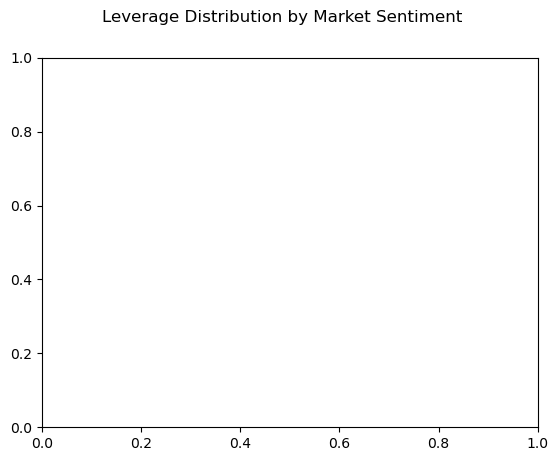

In [96]:

leverage_summary = merged_df_trad.groupby('classification')['Closed PnL'].mean().reset_index()
print(leverage_summary)
sns.boxplot(x='classification', y='Closed PnL', data=merged_df_trad)
plt.suptitle('Leverage Distribution by Market Sentiment')
plt.show()



In [92]:

strategy_df = merged_df_trad.groupby(['classification', 'Side'])['Closed PnL'].mean().reset_index()
print(strategy_df)

Empty DataFrame
Columns: [classification, Side, Closed PnL]
Index: []


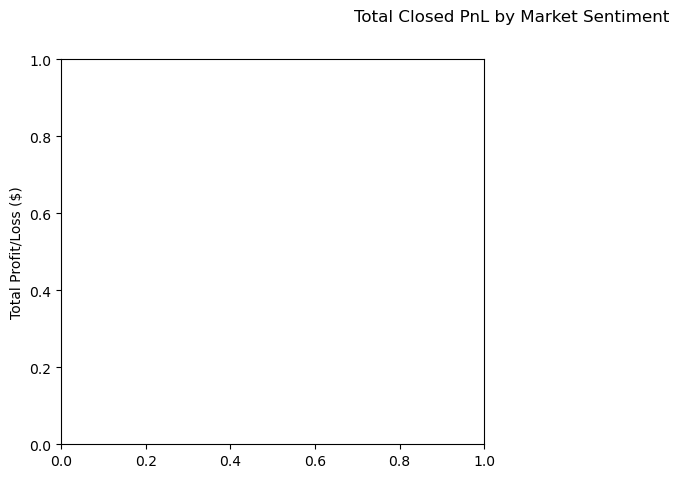

In [97]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=leverage_summary, x='classification', y='Closed PnL', palette='Set2')
plt.suptitle('Total Closed PnL by Market Sentiment')
plt.ylabel('Total Profit/Loss ($)')
plt.show()


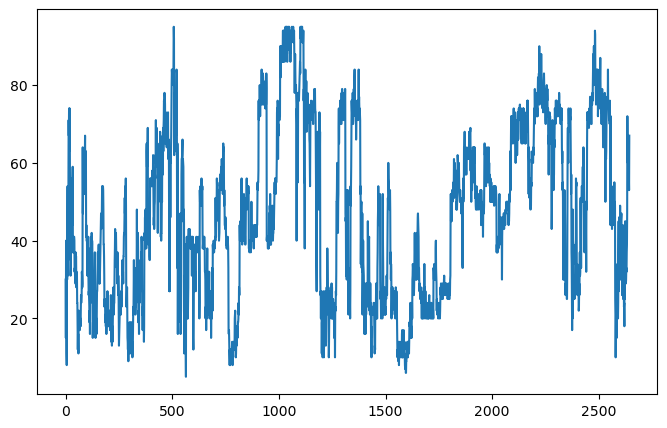

In [94]:
plt.figure(figsize=(8,5))

plt.plot(df_sent['value'])
plt.show()

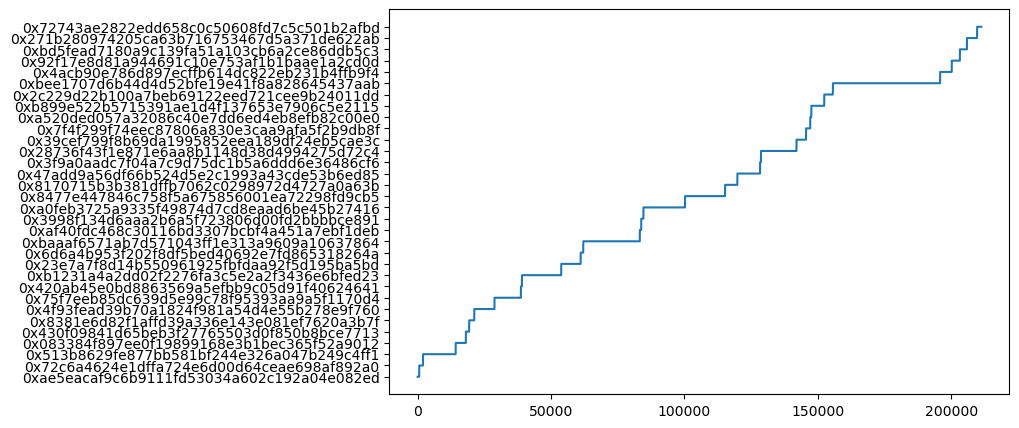

In [95]:
plt.figure(figsize=(8,5))

plt.plot(df_trad['Account'])
plt.show()